In [1]:
import os
import h5py
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_curve, log_loss, brier_score_loss
)
from load_data import load_modality_data
from modality_eval import evaluate_modality
from augmented_modality_eval import aug_evaluate_modality
import numpy as np
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score, 
                           matthews_corrcoef, confusion_matrix)
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz', 'Fpz', 'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO8', 'PO4', 'O2', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'EOG1', 'EOG2']


In [2]:
base_dir = 'h5_freq_c1'
subjects = [2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28]

## Baseline

In [3]:
font = '1F'
condition = 'Par' #put 'Par' for parity, 'Control' for control

### Cross-modality

#### Digits → Number Words

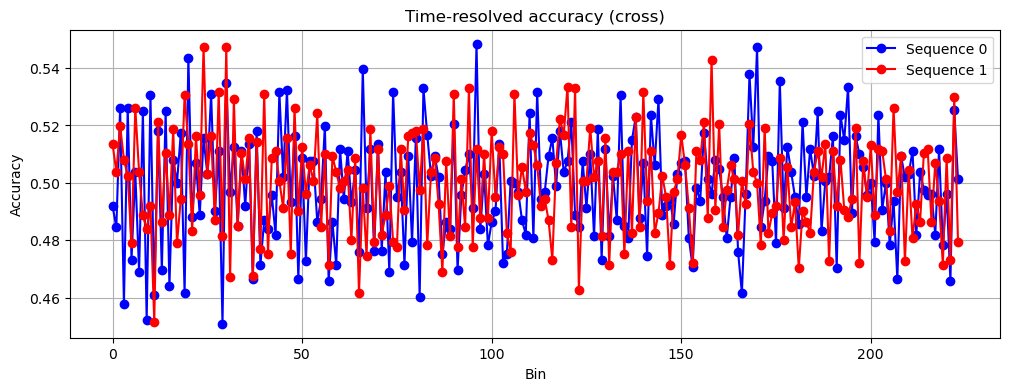

In [21]:
dig_to_words = evaluate_modality(base_dir, subjects, 'Dig', font, condition, 'cross', 'NumWo')

#### Number Words → Digits

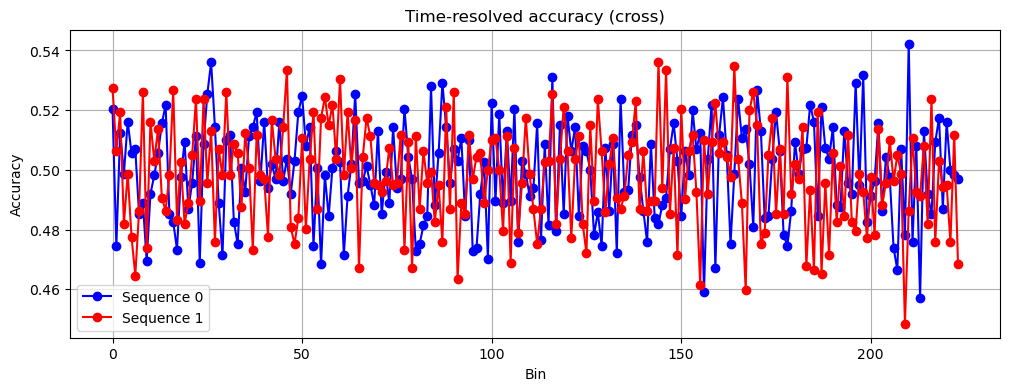

In [22]:
words_to_dig = evaluate_modality(base_dir, subjects, 'NumWo', font, condition, 'cross', 'Dig')

#### Plotting diagnostics


Digits→Words, same condition, same font Performance:
Accuracy: 0.499 (Chance: 0.5)
Balanced Accuracy: 0.499
ROC AUC: 0.499
Matthews CC: -0.002
Support: 2 bins


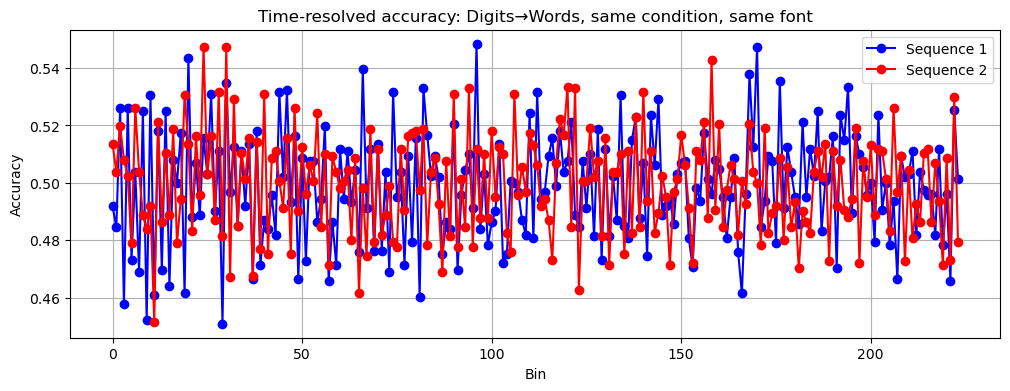


Top 5 Feature Importances:
       feature  importance
8  homogeneity    0.104635
1        theta    0.103964
9       energy    0.102443
2        alpha    0.101369
4        gamma    0.101099

Words→Digits, same condition, same font Performance:
Accuracy: 0.499 (Chance: 0.5)
Balanced Accuracy: 0.499
ROC AUC: 0.498
Matthews CC: -0.002
Support: 2 bins


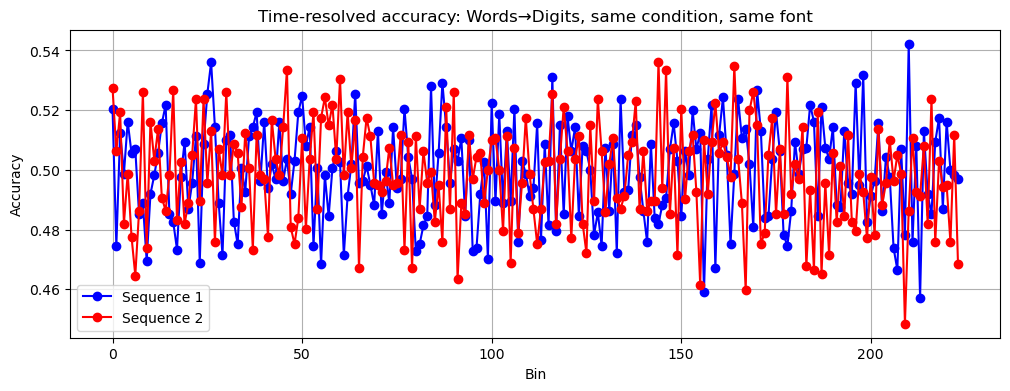


Top 5 Feature Importances:
       feature  importance
8  homogeneity    0.104685
9       energy    0.104299
1        theta    0.103706
0        delta    0.102515
3         beta    0.102237


In [23]:
for name, result in [
    ('Digits→Words, same condition, same font', dig_to_words),
    ('Words→Digits, same condition, same font', words_to_dig)
]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {len(result.get('time_resolved', []))} bins" if 'time_resolved' in result else f"Support: {result.get('support', 'N/A')} samples")
        
        if 'time_resolved' in result:
            bin_acc_all = result['time_resolved']  # list of arrays, one per sequence
            plt.figure(figsize=(12, 4))

            colors = ['blue', 'red']
            for seq_idx, bin_acc in enumerate(bin_acc_all):
                bin_acc = np.array(bin_acc)  # make sure it's an array
                plt.plot(bin_acc[:, 0], bin_acc[:, 1], marker='o', color=colors[seq_idx % len(colors)], label=f'Sequence {seq_idx+1}')

            plt.xlabel('Bin')
            plt.ylabel('Accuracy')
            plt.title(f'Time-resolved accuracy: {name}')
            plt.grid(True)
            plt.legend()
            plt.show()
        
        if 'feature_importances' in result:
            print("\nTop 5 Feature Importances:")
            print(result['feature_importances'].head(5))
    else:
        print(f"\n{name}: No data available")

### Within-modality

#### Digits

In [ ]:
dig_results = evaluate_modality(base_dir, subjects, 'Dig', font, condition, 'within')

#### Number Words (Within Modality)

In [ ]:
numwo_results = evaluate_modality(base_dir, subjects, 'NumWo', font, condition, 'within')

#### Plotting diagnostics

In [ ]:
for name, result in [
    ('Digits→Digits, same condition, same font', dig_results),
    ('Words→Words, same condition, same font', numwo_results)
]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {len(result.get('time_resolved', []))} bins" if 'time_resolved' in result else f"Support: {result.get('support', 'N/A')} samples")
        
        if 'time_resolved' in result:
            bin_acc_all = result['time_resolved']  # list of arrays, one per sequence
            plt.figure(figsize=(12, 4))

            colors = ['blue', 'red']
            for seq_idx, bin_acc in enumerate(bin_acc_all):
                bin_acc = np.array(bin_acc)  # make sure it's an array
                plt.plot(bin_acc[:, 0], bin_acc[:, 1], marker='o', color=colors[seq_idx % len(colors)], label=f'Sequence {seq_idx+1}')

            plt.xlabel('Bin')
            plt.ylabel('Accuracy')
            plt.title(f'Time-resolved accuracy: {name}')
            plt.grid(True)
            plt.legend()
            plt.show()
        
        if 'feature_importances' in result:
            print("\nTop 5 Feature Importances:")
            print(result['feature_importances'].head(5))
    else:
        print(f"\n{name}: No data available")

### Mixed modality

#### Mixed → Digits

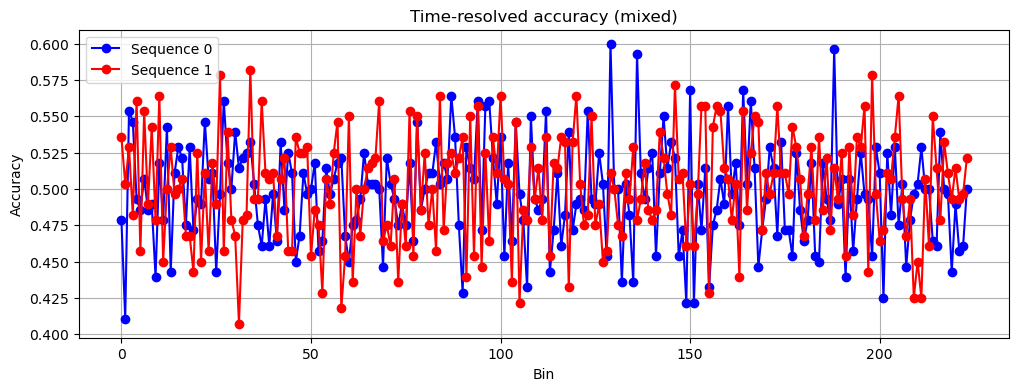

In [5]:
mixed_to_digits = evaluate_modality(base_dir, subjects, 'Dig', font, condition, 'mixed', 'Dig')

#### Mixed → Number Words

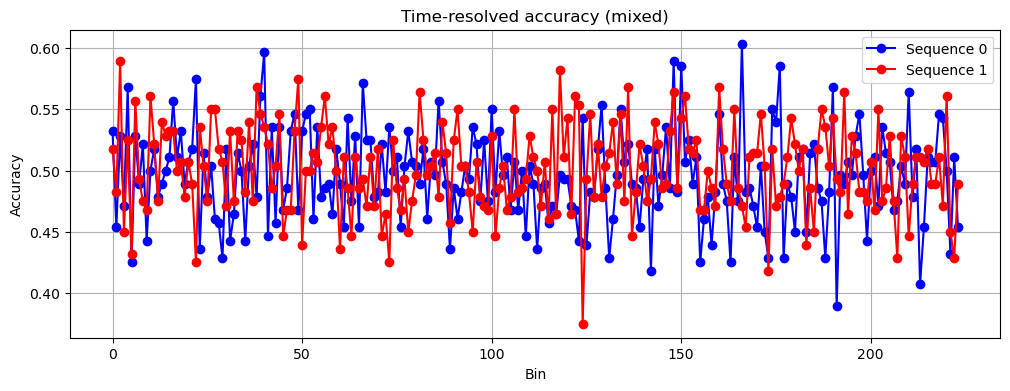

In [6]:
mixed_to_words = evaluate_modality(base_dir, subjects, 'Dig', font, condition, 'mixed', 'NumWo')

#### Plotting diagnostics


Mixed→Digits, same condition, same font Performance:
Accuracy: 0.499 (Chance: 0.5)
Balanced Accuracy: 0.499
ROC AUC: 0.500
Matthews CC: -0.002
Support: 2 bins


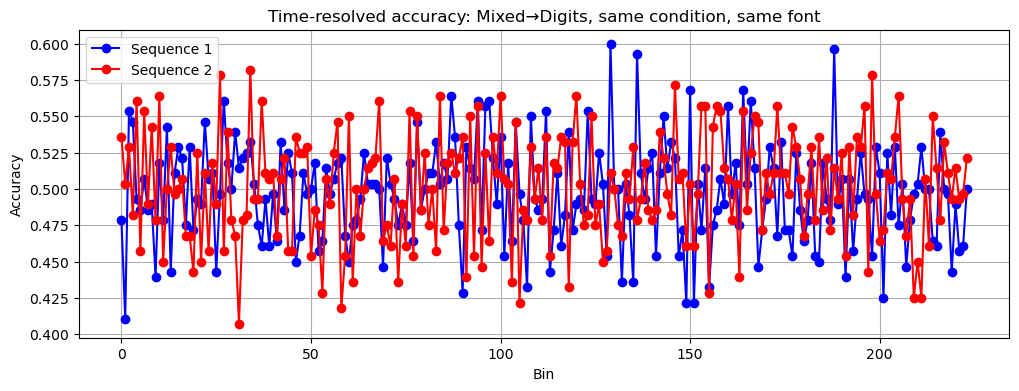


Top 5 Feature Importances:
         feature  importance
4          gamma    0.113107
7    homogeneity    0.113105
0          delta    0.112824
6  dissimilarity    0.111954
1          theta    0.111617

Mixed→Words, same condition, same font Performance:
Accuracy: 0.498 (Chance: 0.5)
Balanced Accuracy: 0.498
ROC AUC: 0.498
Matthews CC: -0.003
Support: 2 bins


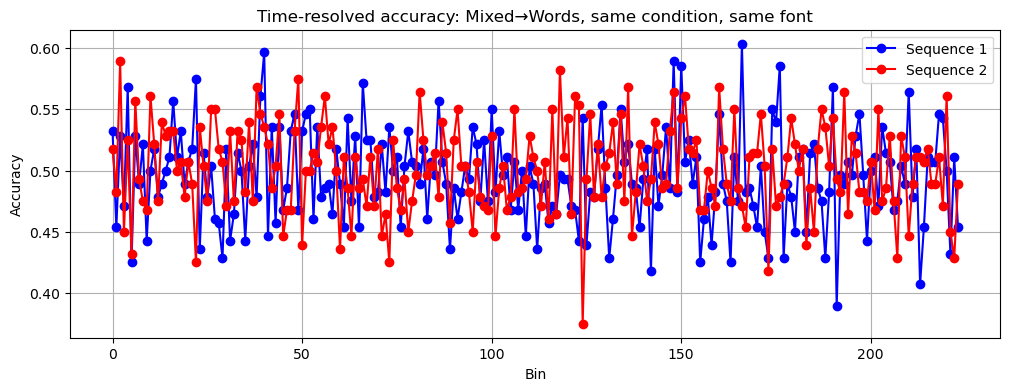


Top 5 Feature Importances:
         feature  importance
6  dissimilarity    0.116246
3           beta    0.114894
8         energy    0.114326
2          alpha    0.113444
0          delta    0.111687


In [7]:
for name, result in [('Mixed→Digits, same condition, same font', mixed_to_digits), 
                    ('Mixed→Words, same condition, same font', mixed_to_words)]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {len(result.get('time_resolved', []))} bins" if 'time_resolved' in result else f"Support: {result.get('support', 'N/A')} samples")
        
        if 'time_resolved' in result:
            bin_acc_all = result['time_resolved']  # list of arrays, one per sequence
            plt.figure(figsize=(12, 4))

            colors = ['blue', 'red']
            for seq_idx, bin_acc in enumerate(bin_acc_all):
                bin_acc = np.array(bin_acc)  # make sure it's an array
                plt.plot(bin_acc[:, 0], bin_acc[:, 1], marker='o', color=colors[seq_idx % len(colors)], label=f'Sequence {seq_idx+1}')

            plt.xlabel('Bin')
            plt.ylabel('Accuracy')
            plt.title(f'Time-resolved accuracy: {name}')
            plt.grid(True)
            plt.legend()
            plt.show()
        
        if 'feature_importances' in result:
            print("\nTop 5 Feature Importances:")
            print(result['feature_importances'].head(5))
    else:
        print(f"\n{name}: No data available")

## Augmented

In [83]:
modality = 'NumWo'
mode = 'cross'
test_mod='Dig' #put None for within

### Font separation

In [16]:
condition = 'Par'

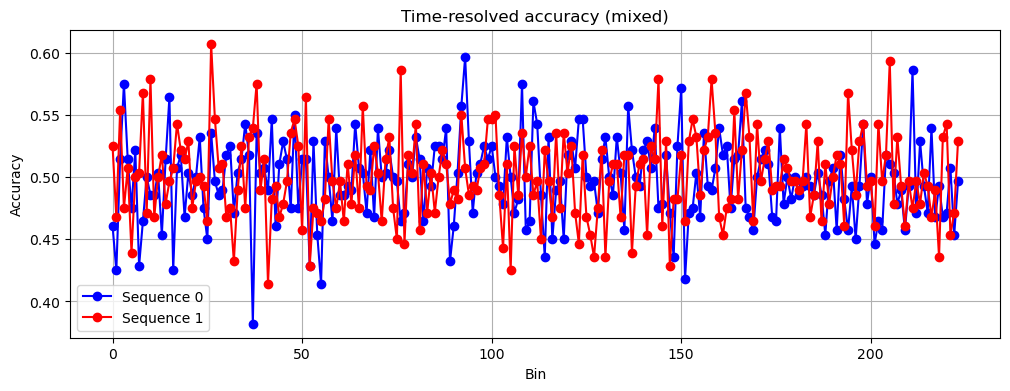

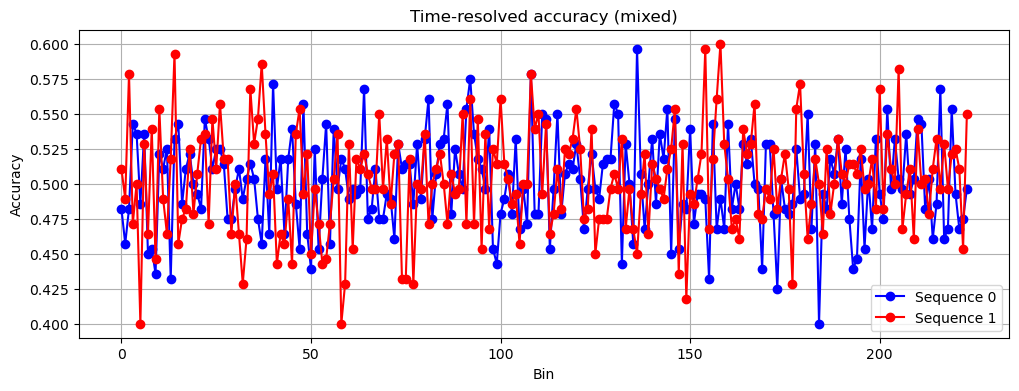

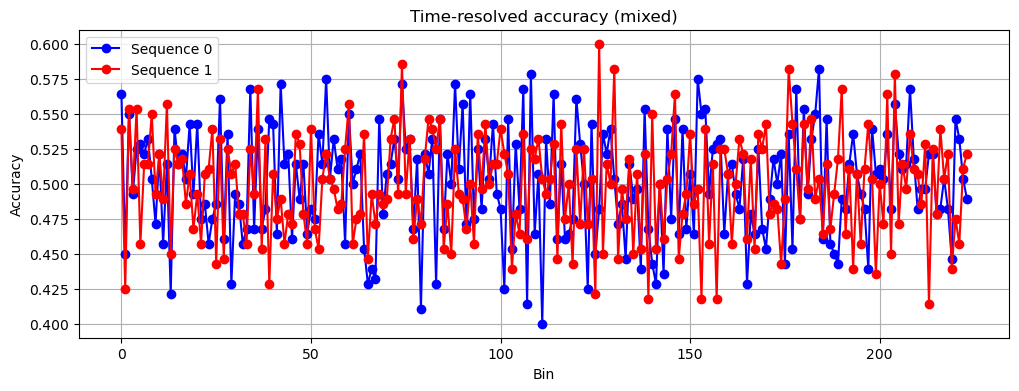

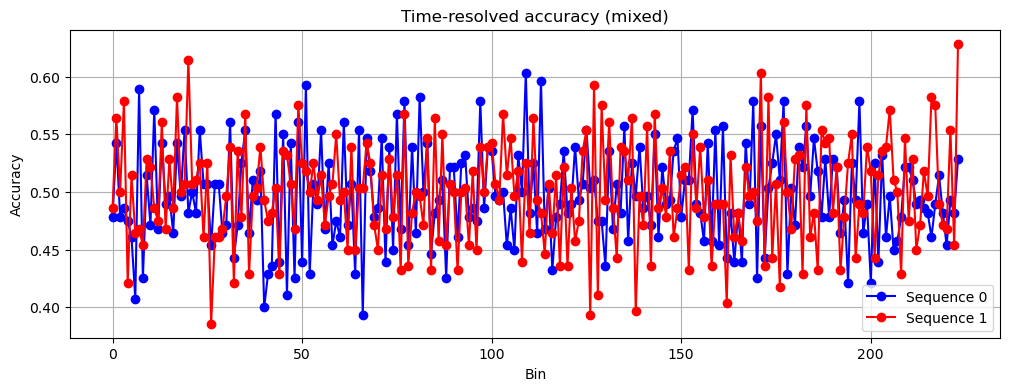

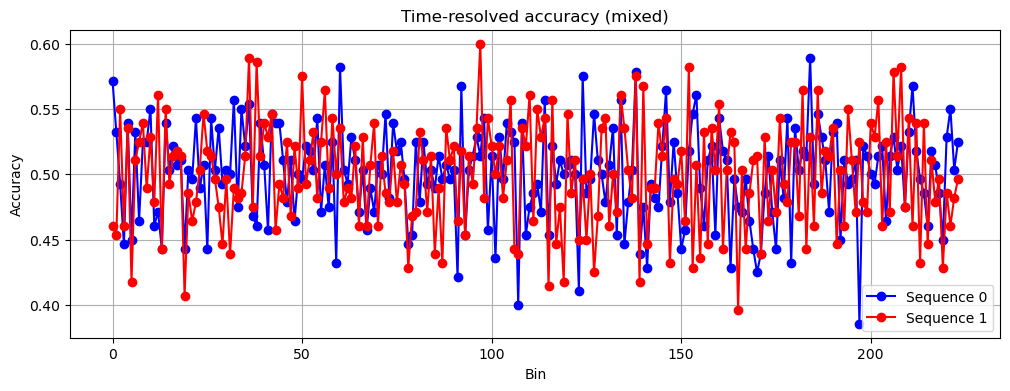

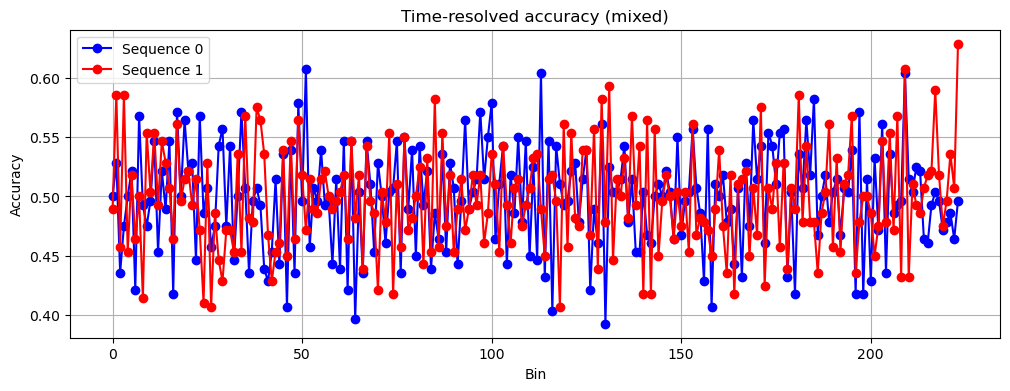

In [17]:
f1_20s = aug_evaluate_modality(base_dir, subjects, modality, 
                          font_train="1F", font_test="20F/S", 
                          condition_train=condition, test_mod=test_mod,
                          mode=mode)
f1_20a = aug_evaluate_modality(base_dir, subjects, modality, 
                          font_train="1F", font_test="20F/A", 
                          condition_train=condition, test_mod=test_mod,
                          mode=mode)
f20a_20s = aug_evaluate_modality(base_dir, subjects, modality, 
                          font_train="20F/A", font_test="20F/S", 
                          condition_train=condition, test_mod=test_mod, 
                          mode=mode)
f20s_20a = aug_evaluate_modality(base_dir, subjects, modality, 
                          font_train="20F/S", font_test="20F/A", 
                          condition_train=condition, test_mod=test_mod,
                          mode=mode)
f20a_1f = aug_evaluate_modality(base_dir, subjects, modality,
                          font_train="20F/A", font_test="1F", 
                          condition_train=condition, test_mod=test_mod,
                          mode=mode)
f20s_1f = aug_evaluate_modality(base_dir, subjects, modality,
                          font_train="20F/S", font_test="1F", 
                          condition_train=condition, test_mod=test_mod,
                          mode=mode)


1F → 20F (S) across Dig, Par, mixed Performance:
Accuracy: 0.499 (Chance: 0.5)
Balanced Accuracy: 0.499
ROC AUC: 0.500
Matthews CC: -0.001
Support: 2 bins


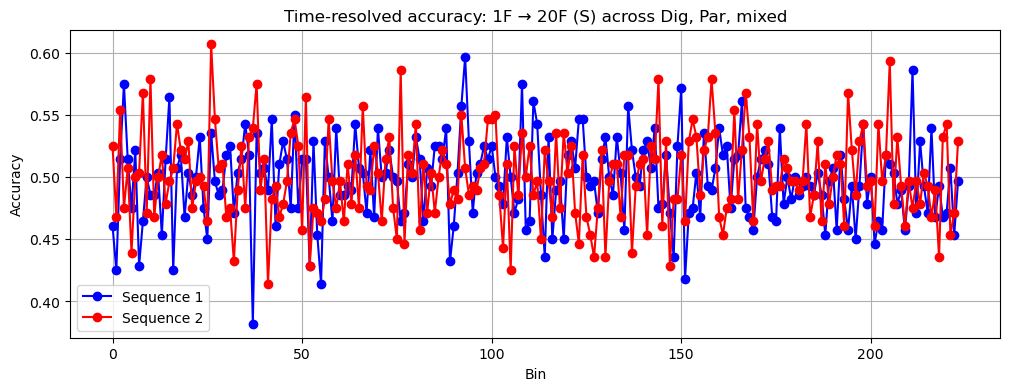


1F → 20F (A) across Dig, Par, mixed Performance:
Accuracy: 0.502 (Chance: 0.5)
Balanced Accuracy: 0.502
ROC AUC: 0.501
Matthews CC: 0.004
Support: 2 bins


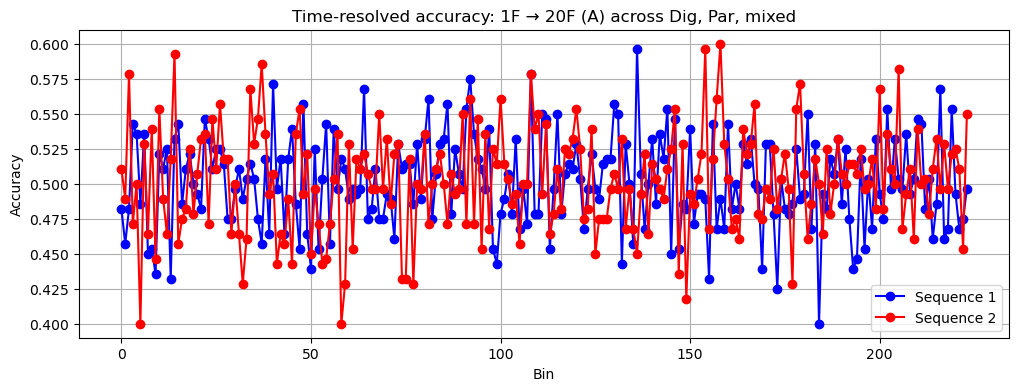


20F (A) → 20F (S) across Dig, Par, mixed Performance:
Accuracy: 0.500 (Chance: 0.5)
Balanced Accuracy: 0.500
ROC AUC: 0.500
Matthews CC: -0.000
Support: 2 bins


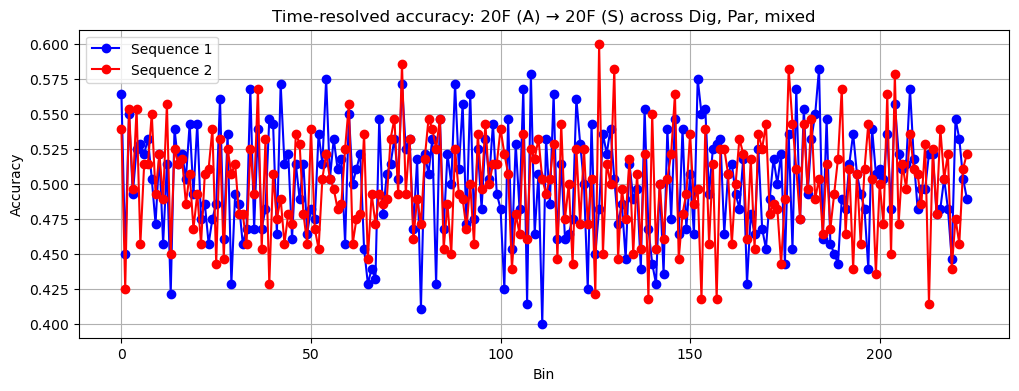


20F (S) → 20F (A) across Dig, Par, mixed Performance:
Accuracy: 0.499 (Chance: 0.5)
Balanced Accuracy: 0.499
ROC AUC: 0.499
Matthews CC: -0.002
Support: 2 bins


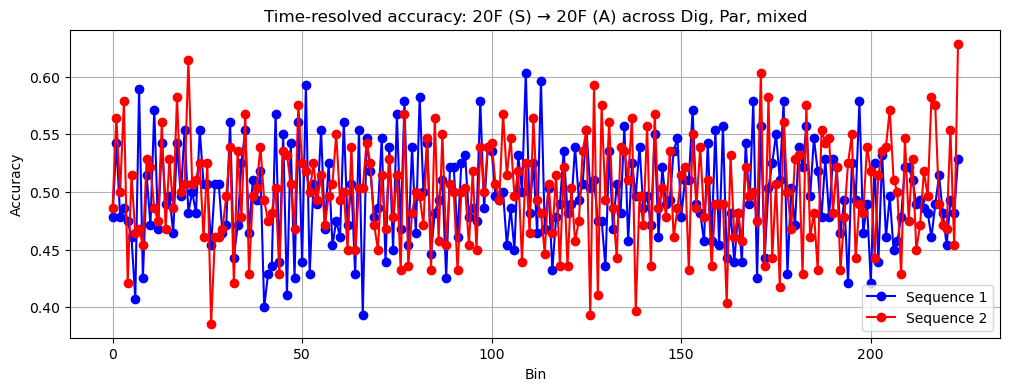


20F (A) → 1F across Dig, Par, mixed Performance:
Accuracy: 0.500 (Chance: 0.5)
Balanced Accuracy: 0.500
ROC AUC: 0.500
Matthews CC: -0.000
Support: 2 bins


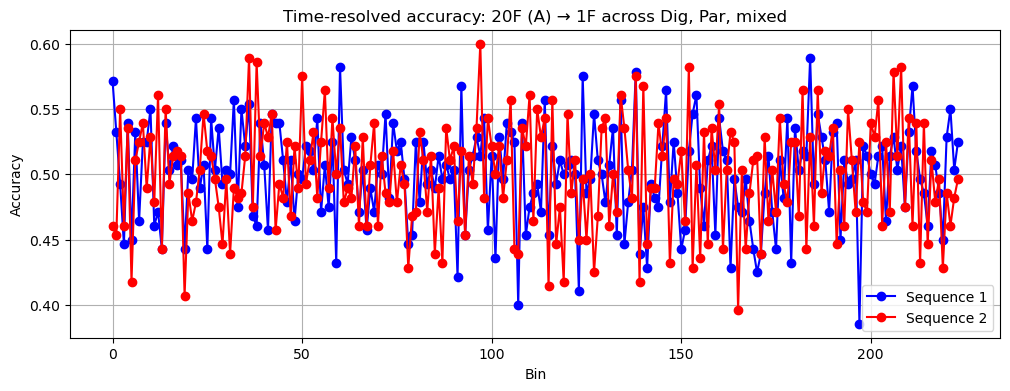


20F (S) → 1F across Dig, Par, mixed Performance:
Accuracy: 0.499 (Chance: 0.5)
Balanced Accuracy: 0.499
ROC AUC: 0.499
Matthews CC: -0.002
Support: 2 bins


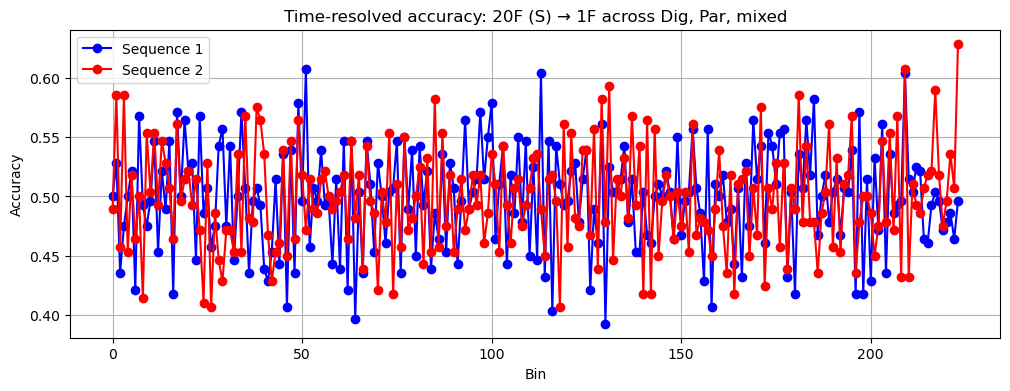

In [18]:
for name, result in [(f'1F → 20F (S) across {modality}, {condition}, {mode}', f1_20s),
                     (f'1F → 20F (A) across {modality}, {condition}, {mode}', f1_20a),
                     (f'20F (A) → 20F (S) across {modality}, {condition}, {mode}', f20a_20s),
                     (f'20F (S) → 20F (A) across {modality}, {condition}, {mode}', f20s_20a),
                     (f'20F (A) → 1F across {modality}, {condition}, {mode}', f20a_1f),
                     (f'20F (S) → 1F across {modality}, {condition}, {mode}', f20s_1f)]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {len(result.get('time_resolved', []))} bins" if 'time_resolved' in result else f"Support: {result.get('support', 'N/A')} samples")
        
        if 'time_resolved' in result:
            bin_acc_all = result['time_resolved']  # list of arrays, one per sequence
            plt.figure(figsize=(12, 4))

            colors = ['blue', 'red']
            for seq_idx, bin_acc in enumerate(bin_acc_all):
                bin_acc = np.array(bin_acc)  # make sure it's an array
                plt.plot(bin_acc[:, 0], bin_acc[:, 1], marker='o', color=colors[seq_idx % len(colors)], label=f'Sequence {seq_idx+1}')

            plt.xlabel('Bin')
            plt.ylabel('Accuracy')
            plt.title(f'Time-resolved accuracy: {name}')
            plt.grid(True)
            plt.legend()
            plt.show()
        
        if 'feature_importances' in result:
            print("\nTop 5 Feature Importances:")
            print(result['feature_importances'].head(5))
    else:
        print(f"\n{name}: No data available")

### Condition separation

In [84]:
font = '20F/S' #put 20F/S or 20F/A for fonts

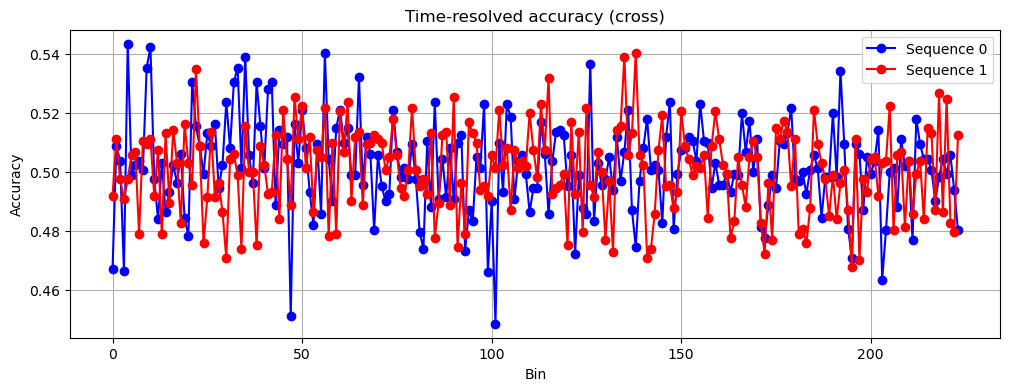

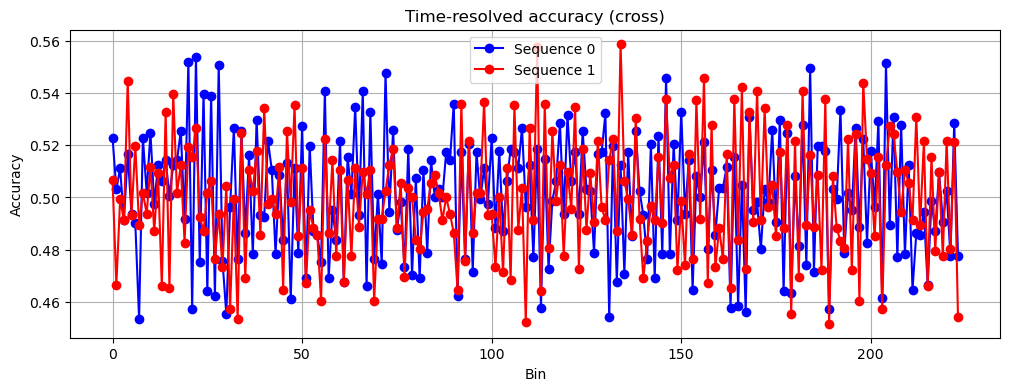

In [85]:
par_c1 = aug_evaluate_modality(base_dir, subjects, modality, 
                     font, condition_train='Par', condition_test='Control',
                     mode=mode, test_mod=test_mod)

c1_par = aug_evaluate_modality(base_dir, subjects, modality, 
                     font, condition_train='Control', condition_test='Par',
                     mode=mode, test_mod=test_mod)


Parity → Control across NumWo, 20F/S, cross Performance:
Accuracy: 0.501 (Chance: 0.5)
Balanced Accuracy: 0.501
ROC AUC: 0.502
Matthews CC: 0.003
Support: 2 bins


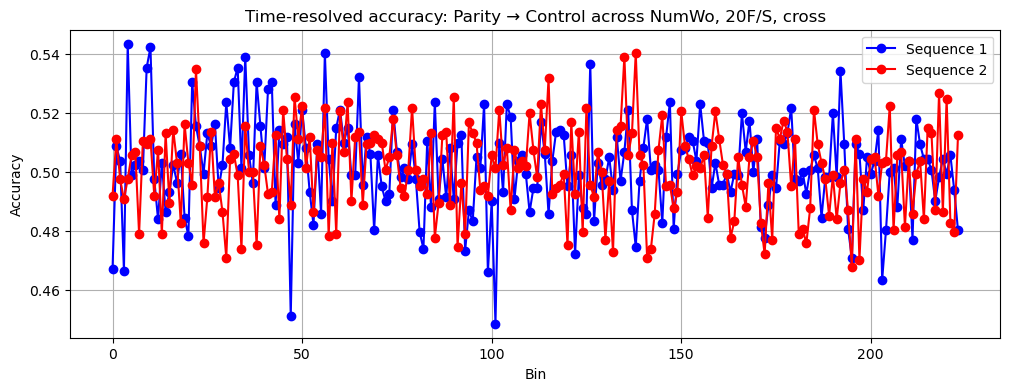


Control → Parity across NumWo, 20F/S, cross Performance:
Accuracy: 0.500 (Chance: 0.5)
Balanced Accuracy: 0.500
ROC AUC: 0.501
Matthews CC: 0.001
Support: 2 bins


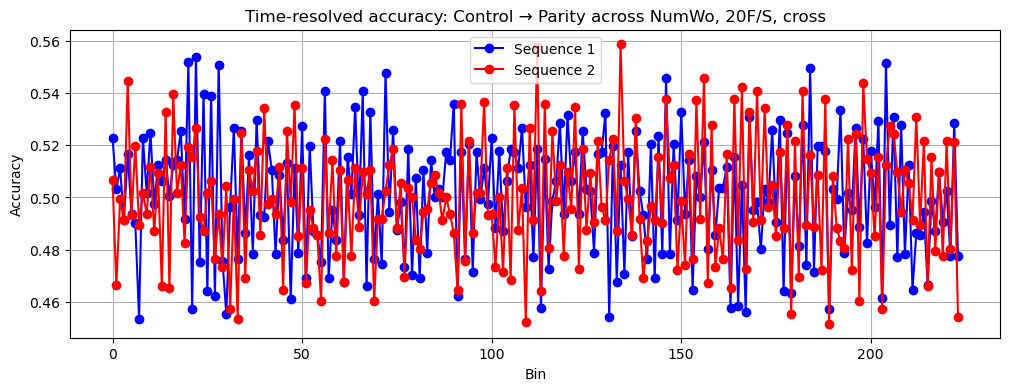

In [86]:
for name, result in [(f'Parity → Control across {modality}, {font}, {mode}', par_c1),
                     (f'Control → Parity across {modality}, {font}, {mode}', c1_par)]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {len(result.get('time_resolved', []))} bins" if 'time_resolved' in result else f"Support: {result.get('support', 'N/A')} samples")
        
        if 'time_resolved' in result:
            bin_acc_all = result['time_resolved']  # list of arrays, one per sequence
            plt.figure(figsize=(12, 4))

            colors = ['blue', 'red']
            for seq_idx, bin_acc in enumerate(bin_acc_all):
                bin_acc = np.array(bin_acc)  # make sure it's an array
                plt.plot(bin_acc[:, 0], bin_acc[:, 1], marker='o', color=colors[seq_idx % len(colors)], label=f'Sequence {seq_idx+1}')

            plt.xlabel('Bin')
            plt.ylabel('Accuracy')
            plt.title(f'Time-resolved accuracy: {name}')
            plt.grid(True)
            plt.legend()
            plt.show()
        
        if 'feature_importances' in result:
            print("\nTop 5 Feature Importances:")
            print(result['feature_importances'].head(5))
    else:
        print(f"\n{name}: No data available")